### Build A Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]



In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [28]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="openai/gpt-oss-120b")

In [29]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000023BEA3609E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000023BEA361260>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [30]:
llm=init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000023BEA361AE0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000023BEA362360>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [31]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [32]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

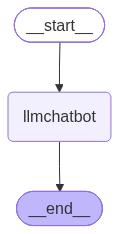

In [33]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [34]:
response=graph.invoke({"messages":"Hi, What is AI Agents?"})

In [35]:
response["messages"][-1].content

'**AI agents** are software entities that perceive their environment, reason about it, and take actions to achieve specific goals. In the field of artificial intelligence, the “agent” metaphor is a way of describing any system that can **sense**, **think**, and **act**—much like a robot, a virtual assistant, or even a piece of code running behind the scenes.\n\nBelow is a quick‑look guide to the core ideas, common types, and real‑world examples.\n\n---\n\n## 1. Core Components of an AI Agent\n\n| Component | What it does | Typical AI techniques used |\n|-----------|--------------|----------------------------|\n| **Perception (Sensors)** | Collects data from the environment (e.g., camera images, text input, game state). | Computer vision, speech recognition, API calls, parsing. |\n| **Knowledge / State** | Stores what the agent knows about the world (current state, history, models). | Knowledge graphs, embeddings, memory buffers. |\n| **Decision‑making (Policy/Planner)** | Chooses the n

In [36]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm doing great, thank you for asking. How can I help you today?


### Chatbot With Tool

In [37]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. [...] langgraph: Framework for building graph-based AI workflows.\n langchain: Popular toolkit for LLM-powered AI applications.\n google-generativeai: Google’s API for Generative AI (Gemini models).\n\n Python  ````\n! pip install langgraph langchain google - generativeai\n```` \n\n### Step 2: Setup Gemini API',
   'score': 0.95386744,
   'raw_content': None,
   'id': '611288-00'},
  {'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM'

In [38]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [39]:
tools=[tool,multiply]

In [40]:
llm_with_tool=llm.bind_tools(tools)

In [41]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000023BEA361AE0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000023BEA362360>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description':

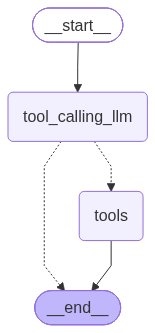

In [42]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [43]:
response=graph.invoke({"messages":"Search Bensly in the web and get the results"})

In [44]:
response['messages'][-1].content

'{"query": "Bensly", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.instagram.com/bensly", "title": "BENSLY® (@bensly) • Instagram photos and videos", "content": "Log In\\n\\nSign Up\\n\\n## bensly\\n\\n 14.2K followers\\n 59 following\\n\\nBENSLY®\\n\\nThe underwear butts dream about.\\n\\n bensly\'s highlight story picture\\n\\n  Dreams\\n\\nPhoto by BENSLY® on April 11, 2018.\\n\\nPhoto by BENSLY® on April 05, 2018.\\n\\nPhoto by BENSLY® on March 25, 2018.\\n\\nPhoto by BENSLY® on March 18, 2018.\\n\\nPhoto by BENSLY® on March 10, 2018.\\n\\nPhoto by BENSLY® on March 09, 2018.\\n\\nPhoto by BENSLY® on March 06, 2018.\\n\\nPhoto by BENSLY® on March 01, 2018.\\n\\nPhoto by BENSLY® on February 17, 2018. [...] Photo by BENSLY® on February 07, 2018.\\n\\nPhoto by BENSLY® on January 27, 2018.\\n\\nPhoto by BENSLY® on January 25, 2018.\\n\\nShow more posts from bensly", "score": 0.532839, "raw_content": null, "id": "83bd46-00"}, {"url": "https:/

In [45]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Search Bensly in the web and get the results
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_b775353d-b2a7-4776-808a-2bb0a4db12c8)
 Call ID: fc_b775353d-b2a7-4776-808a-2bb0a4db12c8
  Args:
    query: Bensly
    search_depth: basic
================================= Tool Message =================================
Name: tavily_search

{"query": "Bensly", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.instagram.com/bensly", "title": "BENSLY® (@bensly) • Instagram photos and videos", "content": "Log In\n\nSign Up\n\n## bensly\n\n 14.2K followers\n 59 following\n\nBENSLY®\n\nThe underwear butts dream about.\n\n bensly's highlight story picture\n\n  Dreams\n\nPhoto by BENSLY® on April 11, 2018.\n\nPhoto by BENSLY® on April 05, 2018.\n\nPhoto by BENSLY® on March 25, 2018.\n\nPhoto by BENSLY® on March 18, 2

In [46]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_281c7314-adee-46e7-9827-6edb2b00cf50)
 Call ID: fc_281c7314-adee-46e7-9827-6edb2b00cf50
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [47]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_2d895821-6bbe-4320-a2bd-ae62994cf901)
 Call ID: fc_2d895821-6bbe-4320-a2bd-ae62994cf901
  Args:
    query: latest AI news September 2026
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://m.economictimes.com/news/international/global-trends/oracle-isnt-alone-these-companies-have-layoffs-scheduled-for-september-2026-as-ai-restructuring-and-cost-cutting-reshape-jobs/articleshow/133324857.cms", "title": "Oracle isn't alone: These companies have layoffs scheduled for September 2026 as AI, restructuring and cost-cutting r

### ReAct Agent Architecture

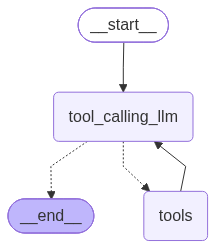

In [48]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [49]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_512a9ba9-d689-47cf-b9bd-9cc23698db91)
 Call ID: fc_512a9ba9-d689-47cf-b9bd-9cc23698db91
  Args:
    query: latest AI news 2024 August
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news 2024 August", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://commission.europa.eu/news-and-media/news/safer-and-more-transparent-ai-2026-08-02_en", "title": "Safer and more transparent AI", "content": "The AI Act entered into force on 1 August 2024. Its provisions apply in stages, with different obligations taking effect at different times. The Act creates a single market and harmonised rules for 

## Adding Memory In Agentic Graph

In [51]:
response=graph.invoke({"messages":"Hello my name is Bensly, can you search for me in the web and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Bensly, can you search for me in the web and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_1b11fd90-9c93-4667-b593-3a5236f0d85d)
 Call ID: fc_1b11fd90-9c93-4667-b593-3a5236f0d85d
  Args:
    query: Bensly
    search_depth: basic
    time_range: None
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "Bensly", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.instagram.com/bensly", "title": "BENSLY® (@bensly) • Instagram photos and videos", "content": "Log In\n\nSign Up\n\n## bensly\n\n 14.2K followers\n 59 following\n\nBENSLY®\n\nThe underwear butts dream about.\n\n bensly's highlight story picture\n\n  Dreams\n\nPhoto by BENSLY® on April 11, 2018.\n\nPhoto by BENSLY® on April 05, 

In [52]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don’t actually have any information about your name. Could you let me know what you’d like me to call you?


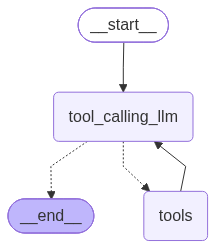

In [53]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [55]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Bensly"},config=config)

response



{'messages': [HumanMessage(content='Hi my name is Krish', additional_kwargs={}, response_metadata={}, id='9fed119d-6192-475d-94e0-6ac726a23b1c'),
  AIMessage(content='Hello Krish! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi my name is Krish". We should greet them and perhaps ask how we can help. No special instructions.'}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 348, 'total_tokens': 408, 'completion_time': 0.123370553, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.004790581, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.162486479, 'total_time': 0.128161134}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5a93aea882', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a017e4-9f53-7902-9f2a-ce20816387c4-0', tool_calls=[], invalid_tool_calls=[], us

In [56]:
response['messages'][-1].content

'Nice to meet you, Bensly! How can I help you today?'

In [57]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is **Bensly**. 😊


In [58]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Yes, you told me your name is **Bensly**. Let me know if there’s anything else you’d like to chat about!


### Streaming

In [59]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [60]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

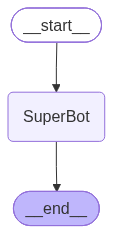

In [61]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [63]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Bensly And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='c04faff1-3a20-4fe9-8cb4-02e07a0bd19c'),
  AIMessage(content='Hey Krish! 👋 Great to meet you.  \n\nCricket’s such a fun sport—whether you’re into the fast‑paced action of T20, the strategic depth of Test cricket, or the classic drama of ODIs. Do you have a favorite team or player you follow? Maybe you’ve got a memorable match or a particular format you love the most? I’d love to hear more about your cricket passions!', additional_kwargs={'reasoning_content': 'The user says: "Hi,My name is Krish And I like cricket". Probably they want a response. We can greet them, ask about cricket, perhaps discuss favorite team, etc. Should be friendly.'}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 82, 'total_tokens': 221, 'completion_time': 0.293213764, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.003089456, 'prompt_t

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [64]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Krish! 👋 Great to meet you. \n\nCricket’s such a fun sport—there’s always something exciting happening on the field. Do you have a favorite team or player you follow? And are you more into the Test format, ODIs, or the fast‑paced action of T20s? Let’s chat cricket!', additional_kwargs={'reasoning_content': 'The user says hi, introduces themselves, likes cricket. We should respond friendly, ask about their cricket interests, maybe ask about favorite team, etc. Follow guidelines: be friendly, ask follow-up. No disallowed content.'}, response_metadata={'token_usage': {'completion_tokens': 124, 'prompt_tokens': 82, 'total_tokens': 206, 'completion_time': 0.258040252, 'completion_tokens_details': {'reasoning_tokens': 46}, 'prompt_time': 0.003128308, 'prompt_tokens_details': None, 'queue_time': 0.376578198, 'total_time': 0.26116856}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_19b184c447', 'service_tier': 'on_demand', 'fini

In [65]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='a4d2f507-9963-4bc8-ae83-a5d827e42717'), AIMessage(content='Hey Krish! 👋 Great to meet you. \n\nCricket’s such a fun sport—there’s always something exciting happening on the field. Do you have a favorite team or player you follow? And are you more into the Test format, ODIs, or the fast‑paced action of T20s? Let’s chat cricket!', additional_kwargs={'reasoning_content': 'The user says hi, introduces themselves, likes cricket. We should respond friendly, ask about their cricket interests, maybe ask about favorite team, etc. Follow guidelines: be friendly, ask follow-up. No disallowed content.'}, response_metadata={'token_usage': {'completion_tokens': 124, 'prompt_tokens': 82, 'total_tokens': 206, 'completion_time': 0.258040252, 'completion_tokens_details': {'reasoning_tokens': 46}, 'prompt_time': 0.003128308, 'prompt_tokens_details': None, 'queue_time': 0.376578198,

In [66]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hi Krish! 👋 Great to meet you.  \n\nCricket’s such an exciting sport—do you have a favorite team or player? Are you more into the fast‑paced T20 format, the classic Test matches, or something else? I'd love to hear what you enjoy most about the game!", additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Krish And I like cricket". Probably they are just greeting and sharing info. We respond friendly, maybe ask about cricket preferences. No policy violation.'}, response_metadata={'token_usage': {'completion_tokens': 112, 'prompt_tokens': 82, 'total_tokens': 194, 'completion_time': 0.231263802, 'completion_tokens_details': {'reasoning_tokens': 41}, 'prompt_time': 0.003302894, 'prompt_tokens_details': None, 'queue_time': 0.321611386, 'total_time': 0.234566696}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_02b0d31eca', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 

In [67]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='1f231a2c-7080-4dbd-99e1-2b434b8736f3'), AIMessage(content="Hi Krish! 👋 Great to meet you.  \n\nCricket’s such an exciting sport—do you have a favorite team or player? Are you more into the fast‑paced T20 format, the classic Test matches, or something else? I'd love to hear what you enjoy most about the game!", additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Krish And I like cricket". Probably they are just greeting and sharing info. We respond friendly, maybe ask about cricket preferences. No policy violation.'}, response_metadata={'token_usage': {'completion_tokens': 112, 'prompt_tokens': 82, 'total_tokens': 194, 'completion_time': 0.231263802, 'completion_tokens_details': {'reasoning_tokens': 41}, 'prompt_time': 0.003302894, 'prompt_tokens_details': None, 'queue_time': 0.321611386, 'total_time': 0.234566696}, 'model_name': 'openai/gpt-os

In [68]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a017e6-e3d5-7721-b5fe-874944e539d5', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='4e44476d-9935-45d4-91a8-ad189e10e2f9')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a017e6-e3fa-7911-87e2-807efd181643', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:91672c76-8279-1043-a501-dfcaf378546a'}, 'parent_ids': ['01a017e6-e3d5-7721-b5fe-874944e539d5']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':